# Radiance Field Network


In [1]:
import time

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import wandb
from torchinfo import summary
from tqdm import tqdm
from utils import read_ground_truth_zip

# GROUND_TRUTH_FILE = '../data/radiance/static_4gb.zip'
# GROUND_TRUTH_FILE = '../data/radiance/oscillate_4gb.zip'
GROUND_TRUTH_FILE = '../data/radiance/colors2.zip'

WANDB_PROJECT = 'neural-volume-illumination'
WANDB_NAME = 'radiance-field-network'

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')


Using device: cuda


In [2]:
data = read_ground_truth_zip(GROUND_TRUTH_FILE, verbose=True)
print(f'Loaded {len(data)} frames from ground truth zip.')
print(f'Frame shape: {data[0].shape}')

Reading ground truth zip: 100%|██████████| 320/320 [00:08<00:00, 37.46it/s]

Loaded 318 frames from ground truth zip.
Frame shape: (262144, 8)


In [3]:
def preprocess_data(data):
    """Remove empty pixels and convert to PyTorch tensors."""
    processed_frames, masks = [], []
    for frame in tqdm(data):
        non_zero_mask = (frame != 0).any(axis=1)
        non_nan_mask = ~np.isnan(frame).any(axis=1)
        valid_mask = non_zero_mask & non_nan_mask
        filtered_frame = frame[valid_mask]
        tensor_frame = torch.from_numpy(filtered_frame).float().to(device)

        # Normalize azimuth and elevation to [0, 1]
        tensor_frame[:, 3] = (tensor_frame[:, 3] + np.pi) / (2.01 * np.pi)
        tensor_frame[:, 4] = tensor_frame[:, 4] / np.pi

        processed_frames.append(tensor_frame)
        masks.append(valid_mask)

    return processed_frames, masks


processed_data, masks = preprocess_data(data)
Xs = [frame[:, :5] for frame in processed_data]
ys = [frame[:, 5:] for frame in processed_data]

100%|██████████| 318/318 [00:02<00:00, 121.03it/s]


In [4]:
class MultiresolutionHashEncoding(nn.Module):
    """Multiresolution Hash Encoding from the paper "Instant Neural Graphics
    Primitives with a Multiresolution Hash Encoding" by Müller et al. (2022).

    Parameters:
        - input_dim: 2 for angles, 3 for positions.             ... d
        - hash_table_size: Maximum size of each hash table.     ... T
        - fine_res: Resolution of the finest level.             ... N_max
        - levels: Number of levels in the hierarchy.            ... L
        - feature_dim: Number of features per level.            ... F
        - coarse_res: Resolution of the coarsest level.         ... N_min

    According to the paper, only the hash table size and fine resolution
    need to be tuned to the task.

    Paper: https://arxiv.org/pdf/2201.05989
    """

    def __init__(
        self,
        input_dim,
        hash_table_size=14,
        fine_res=512,
        *,
        levels=16,
        feature_dim=2,
        coarse_res=16,
    ):
        super().__init__()
        self.L = levels
        self.T = 2**hash_table_size
        self.F = feature_dim
        self.N_min = coarse_res
        self.N_max = fine_res

        assert input_dim in [2, 3], (
            'Input dimension must be either 2 (direction) or 3 (position).'
        )
        self.d = input_dim

        self.b = np.exp((np.log(self.N_max) - np.log(self.N_min)) / (self.L - 1))
        self.N_l = [int(self.N_min * (self.b**level)) for level in range(self.L)]

        self.tables = nn.ModuleList(
            [nn.Embedding(self._table_size(level), self.F) for level in range(self.L)]
        )

    def _table_size(self, level):
        # Embedding tables for coarser levels can be smaller
        return min((self.N_l[level] + 1) ** self.d, self.T)

    def _spatial_hash(self, x):
        primes = torch.tensor(
            [1, 2654435761, 805459861], device=x.device, dtype=x.dtype
        )[: self.d]

        hashed = torch.bitwise_xor((x * primes)[..., 0], (x * primes)[..., 1])
        if self.d == 3:
            hashed = torch.bitwise_xor(hashed, (x * primes)[..., 2])

        return hashed % self.T

    def _one_one_mapping(self, x, N_l):
        res = N_l + 1
        powers = res ** torch.arange(self.d, device=x.device).flip(0)
        return (x * powers).sum(dim=-1)

    def _hash_fn(self, corners, N_l, one_one_mapping):
        return (
            self._one_one_mapping(corners, N_l)
            if one_one_mapping
            else self._spatial_hash(corners)
        )

    def forward(self, x):
        features = []

        for N_l, table in zip(self.N_l, self.tables):
            # Compute top left (or front) corner of the voxel containing x
            # shape: (batch_size, d)
            voxel_corner = torch.floor(x * N_l)

            # Create all 4 or 8 corner indices
            # shape: (batch_size, 2^d, d)
            offsets = torch.cartesian_prod(
                *[torch.tensor([0, 1], device=x.device)] * self.d
            ).unsqueeze(0)
            corners = voxel_corner.unsqueeze(1) + offsets

            one_one = (N_l + 1) ** self.d <= self.T

            # 1. Hashing (finer levels) of 1:1 mapping (coarser levels)
            # shape: (batch_size, 2^d)
            indices = self._hash_fn(corners.long(), N_l, one_one)

            # 2. Lookup
            # shape: (batch_size, 2^d, F)
            embeddings = table(indices)

            # 3. Linear interpolation w_l := x_l - floor(x_l)
            # shape: (batch_size, 2^d)
            w_l = (x * N_l - voxel_corner).unsqueeze(1)
            corner_weights = offsets * w_l + (1 - offsets) * (1 - w_l)
            w = corner_weights.prod(dim=-1)

            # shape: (batch_size, F)
            weighted = (embeddings * w.unsqueeze(-1)).sum(dim=1)
            features.append(weighted)

        # 4. Concatenation of all levels
        return torch.cat(features, dim=-1)

In [5]:
class RadianceFieldNetwork(nn.Module):
    def __init__(
        self,
        layers=5,
        hidden_dim=64,
        encoding=True,
        log_radiance=False,
        psi=4,
        levels=16,
        feature_dim=2,
        pos_fine_res=512,
        dir_fine_res=128,
        pos_coarse_res=16,
        dir_coarse_res=16,
        hash_table_size=14,
    ):
        super().__init__()

        if encoding:
            self.position_encoding = MultiresolutionHashEncoding(
                3,
                hash_table_size,
                pos_fine_res,
                levels=levels,
                feature_dim=feature_dim,
                coarse_res=pos_coarse_res,
            )
            self.direction_encoding = MultiresolutionHashEncoding(
                2,
                hash_table_size,
                dir_fine_res,
                levels=levels,
                feature_dim=feature_dim,
                coarse_res=dir_coarse_res,
            )
            pos_size = self.position_encoding.L * self.position_encoding.F
            dir_size = self.direction_encoding.L * self.direction_encoding.F
        else:
            self.position_encoding = nn.Identity()
            self.direction_encoding = nn.Identity()
            pos_size = 3
            dir_size = 2

        assert layers >= 1, 'Number of layers must be at least 1.'

        self.fc = nn.ModuleList(
            [
                nn.Linear(
                    pos_size + dir_size if i == 0 else hidden_dim,
                    3 if i == layers - 1 else hidden_dim,
                )
                for i in range(layers)
            ]
        )

        self.log_radiance = log_radiance
        self.psi = psi

    def forward(self, x):
        pos = self.position_encoding(x[:, :3])
        dir = self.direction_encoding(x[:, 3:])
        x = torch.cat([pos, dir], dim=-1)
        for layer in self.fc:
            x = torch.relu(layer(x))
        if self.log_radiance:
            x = torch.pow(10, -x * self.psi)
        return x

In [6]:
summary(RadianceFieldNetwork(), input_size=(Xs[0].shape[0], 5))

Layer (type:depth-idx)                   Output Shape              Param #
RadianceFieldNetwork                     [118637, 3]               --
├─MultiresolutionHashEncoding: 1-1       [118637, 32]              --
│    └─ModuleList: 2-1                   --                        --
│    │    └─Embedding: 3-1               [118637, 8, 2]            9,826
│    │    └─Embedding: 3-2               [118637, 8, 2]            18,522
│    │    └─Embedding: 3-3               [118637, 8, 2]            32,768
│    │    └─Embedding: 3-4               [118637, 8, 2]            32,768
│    │    └─Embedding: 3-5               [118637, 8, 2]            32,768
│    │    └─Embedding: 3-6               [118637, 8, 2]            32,768
│    │    └─Embedding: 3-7               [118637, 8, 2]            32,768
│    │    └─Embedding: 3-8               [118637, 8, 2]            32,768
│    │    └─Embedding: 3-9               [118637, 8, 2]            32,768
│    │    └─Embedding: 3-10              [118637, 

In [7]:
def create_image(model, X, y, mask, original_shape=(512, 512, 3)):
    original, predicted = np.zeros(original_shape), np.zeros(original_shape)
    original_flat = original.reshape(-1, 3)
    predicted_flat = predicted.reshape(-1, 3)
    original_cpu = y.detach().cpu().numpy()

    model.eval()
    predicted_cpu = model(X).detach().cpu().numpy()

    indices = np.where(mask)[0]
    original_flat[indices] = original_cpu
    predicted_flat[indices] = predicted_cpu
    return original, predicted


def radiance_exponents(y, psi=4):
    return torch.pow(
        10,
        -torch.where(
            y > 1 / 10**psi,
            -torch.log10(y) / psi,
            1,
        ),
    )


In [ ]:
def _train_model(Xs, ys, epochs, lr, step_size, gamma, model_args, verbose=False):
    """Train the Radiance Field Network on the given data with specified
    hyperparameters.

    Parameters:
        - Xs: List of input tensors for each frame.
        - ys: List of target tensors for each frame.
        - epochs: Number of training epochs for each frame.
        - lr: Learning rate for the optimizer.
        - step_size: Step size for learning rate scheduler.
        - gamma: Multiplicative factor for learning rate decay.
        - model_args: Dictionary of arguments to initialize the RadianceFieldNetwork.
        - verbose: If True, print training progress and losses.

    Returns:
        - model
        - training losses
        - validation losses
        - baseline losses
    """
    model = RadianceFieldNetwork(**model_args).to(device)
    loss_fn = nn.MSELoss(reduction='mean')
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=step_size, gamma=gamma)

    baseline_losses = []
    train_losses = []
    val_losses = []

    iter = enumerate(zip(Xs, ys))
    if verbose:
        iter = tqdm(iter, total=len(Xs))

    with wandb.init(settings=wandb.Settings(reinit='return_previous')) as run:
        for i, (X, y) in iter:
            if 'log_radiance' in model_args and model_args['log_radiance']:
                y = radiance_exponents(y, psi=model.psi)

            # Validate on data before using it for training
            model.eval()
            val_loss = loss_fn(model(X), y).item()

            model.train()
            start = time.perf_counter()
            for _ in range(epochs):
                optimizer.zero_grad()
                outputs = model(X)
                loss = loss_fn(outputs, y)
                loss.backward()
                optimizer.step()
            end = time.perf_counter()

            scheduler.step()

            mean_predicts = y.mean(dim=0).unsqueeze(0).expand_as(y)
            baseline_losses.append(loss_fn(mean_predicts, y).item())
            train_losses.append(loss.item())
            val_losses.append(val_loss)

            if verbose:
                iter.set_postfix(
                    train_loss=loss.item(),
                    val_loss=val_loss,
                    ms=(end - start) * 1000,
                )

            run.log(
                {
                    'train_loss': train_losses[-1],
                    'val_loss': val_losses[-1],
                    'baseline_loss': baseline_losses[-1],
                    'ms': (end - start) * 1000,
                }
            )

    return model, train_losses, val_losses, baseline_losses


In [9]:
def train_model(Xs, ys, epochs, lr, step_size, gamma, model_args, verbose=False):
    with wandb.init(
        project=WANDB_PROJECT,
        name=WANDB_NAME,
        config={
            'epochs': epochs,
            'learning_rate': lr,
            'step_size': step_size,
            'gamma': gamma,
            **model_args,
        },
    ):
        return _train_model(Xs, ys, epochs, lr, step_size, gamma, model_args, verbose)


wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/blaz/.netrc.
wandb: Currently logged in as: blazerzar (blazerzar-team) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


  0%|          | 0/317 [00:00<?, ?it/s]

100%|██████████| 317/317 [00:32<00:00,  9.77it/s, ms=59.7, train_loss=0.0707, val_loss=0.0707]


baseline_loss,▃▃▅▅▂█▇▆▇█▆▆▅▅▄▅▆▆▇▇▇▆▆▃▃▆▇▁▇▄▄▅▅█▅▇▆▃▃▅
train_loss,█▃▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁
val_loss,█▃▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁
baseline_loss,0.08173
train_loss,0.07069
val_loss,0.07071


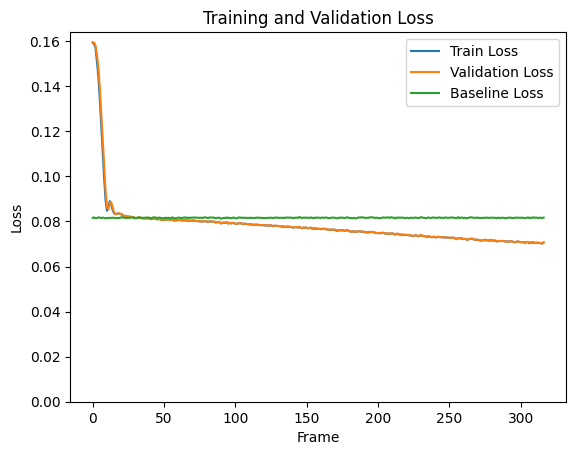

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.1705691814422607].


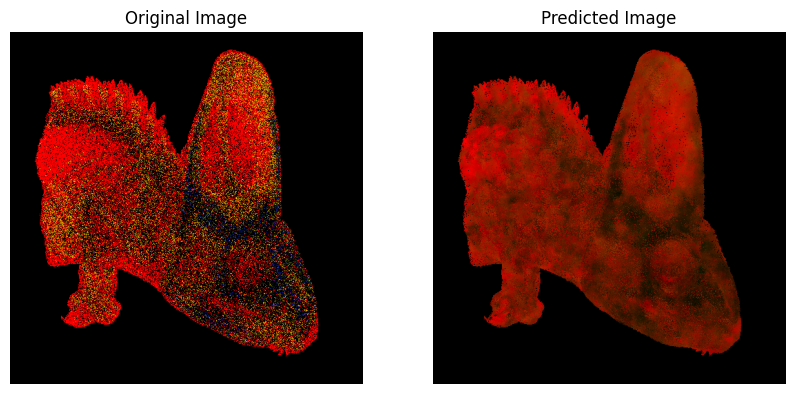

In [ ]:
model, train_losses, val_losses, baseline_losses = train_model(
    Xs[:-1],
    ys[:-1],
    epochs=10,
    lr=1e-3,
    step_size=500,
    gamma=0.5,
    model_args={
        'layers': 5,
        'hidden_dim': 64,
        'encoding': True,
        'log_radiance': False,
        'psi': 4,
        'levels': 16,
        'feature_dim': 2,
        'pos_fine_res': 512,
        'dir_fine_res': 128,
        'pos_coarse_res': 16,
        'dir_coarse_res': 16,
        'hash_table_size': 8,
    },
    verbose=True,
)


plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.plot(baseline_losses, label='Baseline Loss')
plt.xlabel('Frame')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.ylim(bottom=0)
plt.legend()
plt.show()

original, predicted = create_image(model, Xs[-1], ys[-1], masks[-1])

_, ax = plt.subplots(1, 2, figsize=(10, 6))
ax[0].imshow(original)
ax[0].set_title('Original Image')
ax[0].axis('off')
ax[1].imshow(predicted)
ax[1].set_title('Predicted Image')
ax[1].axis('off')
plt.show()

## Hyperparameter Tuning

In [ ]:
def train_model_sweep():
    with wandb.init(project=WANDB_PROJECT, name=WANDB_NAME) as run:
        epochs = run.config.epochs
        lr = run.config.learning_rate
        step_size = run.config.step_size
        gamma = run.config.gamma
        model_args = {
            'layers': run.config.layers,
            'hidden_dim': run.config.hidden_dim,
            'encoding': run.config.encoding,
            'log_radiance': run.config.log_radiance,
            'levels': run.config.levels,
            'feature_dim': run.config.feature_dim,
            'pos_fine_res': run.config.pos_fine_res,
            'dir_fine_res': run.config.dir_fine_res,
            'pos_coarse_res': run.config.pos_coarse_res,
            'dir_coarse_res': run.config.dir_coarse_res,
            'hash_table_size': run.config.hash_table_size,
        }
        model, train_losses, val_losses, baseline_losses = _train_model(
            Xs, ys, epochs, lr, step_size, gamma, model_args
        )

        run.log(
            {
                'train_loss': train_losses,
                'val_loss': val_losses,
                'baseline_loss': baseline_losses,
            }
        )

        return model, train_losses, val_losses, baseline_losses


sweep_configuration = {
    'name': WANDB_NAME,
    'method': 'bayes',
    'metric': {'goal': 'minimize', 'name': 'val_loss'},
    'parameters': {
        'layers': {'values': [3, 4, 5, 6, 7, 8]},
        'hidden_dim': {'values': [16, 32, 64, 128]},
        'encoding': {'values': [True, False]},
        'log_radiance': {'values': [True, False]},
        'levels': {'min': 4, 'max': 22},
        'feature_dim': {'min': 2, 'max': 8},
        'pos_fine_res': {'values': [128, 256, 512]},
        'dir_fine_res': {'values': [64, 128, 256]},
        'pos_coarse_res': {'values': [8, 16, 32]},
        'dir_coarse_res': {'values': [8, 16, 32]},
        'hash_table_size': {'min': 6, 'max': 24},
    },
}

sweep_id = wandb.sweep(sweep_configuration, project=WANDB_PROJECT)
wandb.agent(sweep_id, function=train_model, count=100)